In [ ]:
**PROJECT TITLE**
Retail Sales Data Analysis

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")

In [16]:
df = pd.read_csv("../data/sales.csv")

df.head()

,CustomerID,Region,Sales,Discount,Date,ProductID,Quantity,Return,CustomerType,SalesChannel,PaymentMethod,SatisfactionScore,ProductCategory
0,1001,East,21708.779879,NaN,2024-02-27 03:21:48.108108104,164,16,0,VIP,Online,Credit Card,3,Electronics
1,1002,West,29380.854196,5.0,2024-05-09 22:40:43.243243240,156,22,0,New,In-Store,Bank Transfer,6,Sports
2,1003,North,24752.119191,15.0,2024-05-01 00:05:45.945945944,192,85,0,New,In-Store,Credit Card,2,Health & Beauty
3,1004,East,17115.481722,5.0,2024-08-25 20:59:49.189189184,198,54,0,Returning,Direct,Cash,10,Sports
4,1005,East,15507.926643,NaN,2024-05-31 15:48:28.108108104,139,21,0,New,In-Store,Credit Card,1,Sports


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         1000 non-null   int64  
 1   Region             970 non-null    object 
 2   Sales              950 non-null    float64
 3   Discount           723 non-null    float64
 4   Date               1000 non-null   object 
 5   ProductID          1000 non-null   int64  
 6   Quantity           1000 non-null   int64  
 7   Return             1000 non-null   int64  
 8   CustomerType       1000 non-null   object 
 9   SalesChannel       1000 non-null   object 
 10  PaymentMethod      1000 non-null   object 
 11  SatisfactionScore  1000 non-null   int64  
 12  ProductCategory    1000 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 101.7+ KB


In [20]:
df.describe()

,CustomerID,Sales,Discount,ProductID,Quantity,Return,SatisfactionScore
count,1000.000000,950.000000,723.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,1500.500000,20241.792218,10.000000,149.45100,50.321000,0.091000,5.559000
std,288.819436,5043.372428,4.076825,28.34221,27.920557,0.287753,3.004921
min,1001.000000,5518.723109,5.000000,100.00000,1.000000,0.000000,1.000000
25%,1250.750000,16866.920156,5.000000,126.00000,27.000000,0.000000,3.000000
50%,1500.500000,20233.542855,10.000000,148.00000,51.000000,0.000000,6.000000
75%,1750.250000,23488.595382,15.000000,174.00000,74.000000,0.000000,8.000000
max,2000.000000,35394.404042,15.000000,199.00000,99.000000,1.000000,10.000000


In [22]:
df['Date'] = pd.to_datetime(df['Date'])

In [24]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

In [26]:
df.isnull().sum()

CustomerID             0
Region                30
Sales                 50
Discount             277
Date                   0
ProductID              0
Quantity               0
Return                 0
CustomerType           0
SalesChannel           0
PaymentMethod          0
SatisfactionScore      0
ProductCategory        0
Year                   0
Month                  0
dtype: int64

In [28]:
df = df.drop_duplicates()

In [32]:
df.columns

Index(['CustomerID', 'Region', 'Sales', 'Discount', 'Date', 'ProductID',
       'Quantity', 'Return', 'CustomerType', 'SalesChannel', 'PaymentMethod',
       'SatisfactionScore', 'ProductCategory', 'Year', 'Month'],
      dtype='object')

In [36]:
total_revenue = df['Sales'].sum()
total_orders = df['CustomerID'].count()
total_quantity = df['Quantity'].sum()
avg_sales = df['Sales'].mean()

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Total Quantity Sold:", total_quantity)
print("Average Sales:", avg_sales)

Total Revenue: 19229702.607530933
Total Orders: 1000
Total Quantity Sold: 50321
Average Sales: 20241.792218453615


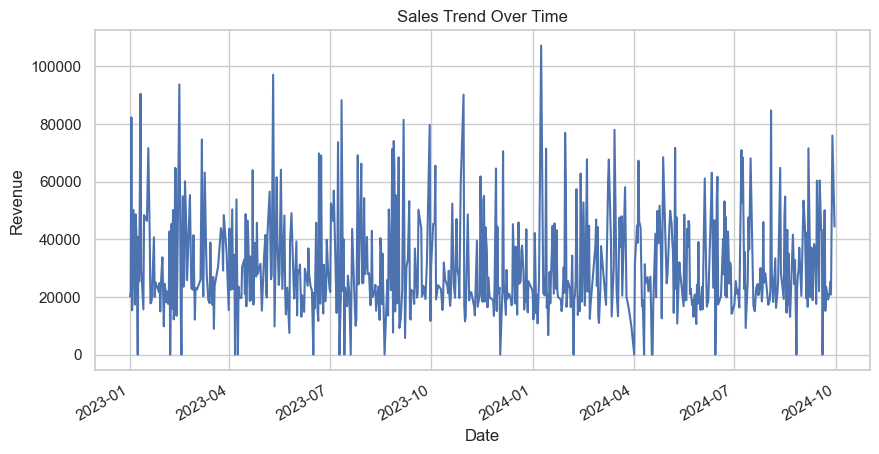

In [38]:
sales_trend = df.groupby('Date')['Sales'].sum()

plt.figure(figsize=(10,5))
sales_trend.plot()

plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()

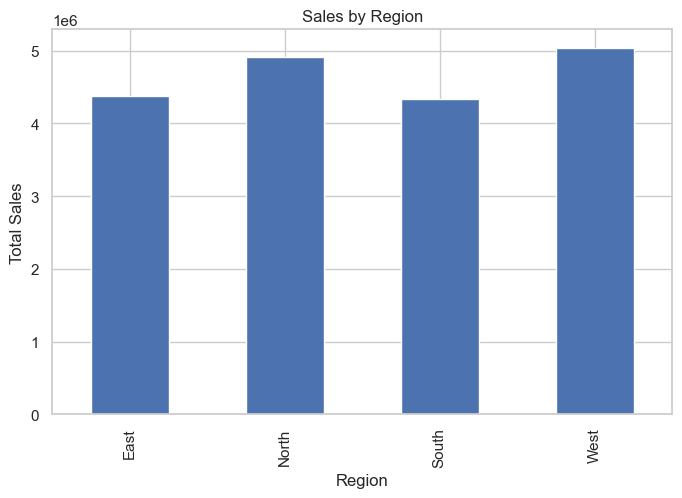

In [40]:
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(8,5))
region_sales.plot(kind='bar')

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

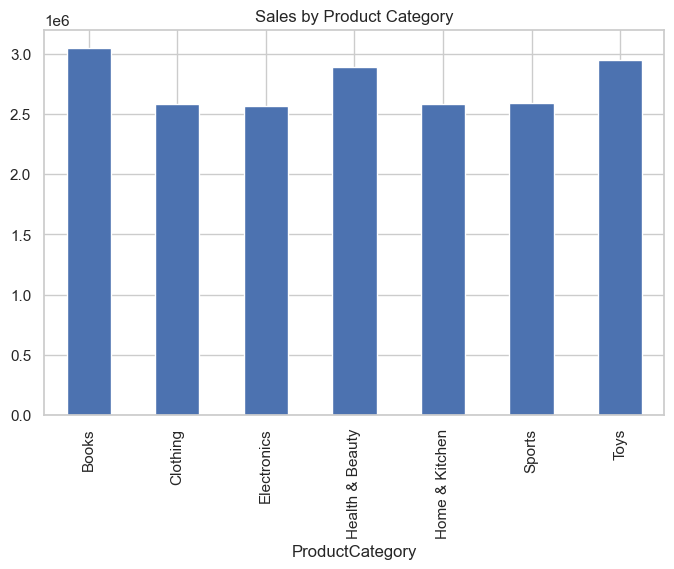

In [42]:
category_sales = df.groupby('ProductCategory')['Sales'].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')

plt.title("Sales by Product Category")

plt.show()

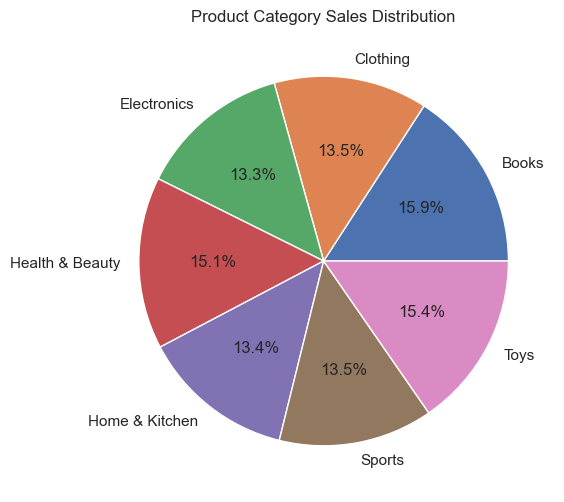

In [44]:
plt.figure(figsize=(6,6))

plt.pie(category_sales,
        labels=category_sales.index,
        autopct='%1.1f%%')

plt.title("Product Category Sales Distribution")

plt.show()

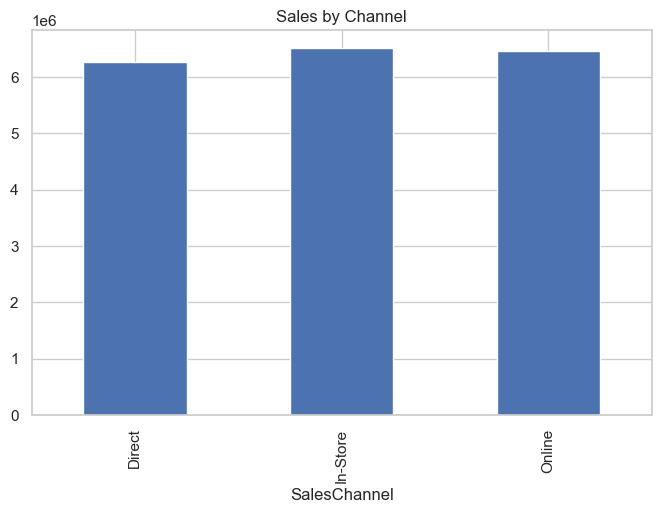

In [46]:
channel_sales = df.groupby('SalesChannel')['Sales'].sum()

plt.figure(figsize=(8,5))
channel_sales.plot(kind='bar')

plt.title("Sales by Channel")

plt.show()

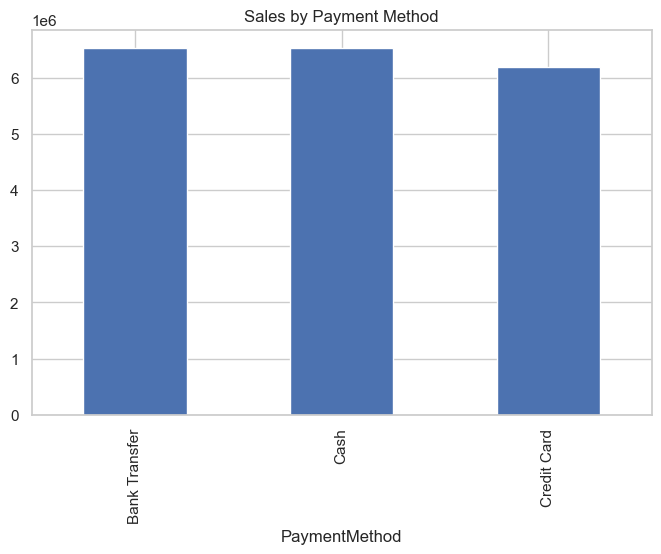

In [48]:
payment_sales = df.groupby('PaymentMethod')['Sales'].sum()

plt.figure(figsize=(8,5))
payment_sales.plot(kind='bar')

plt.title("Sales by Payment Method")

plt.show()

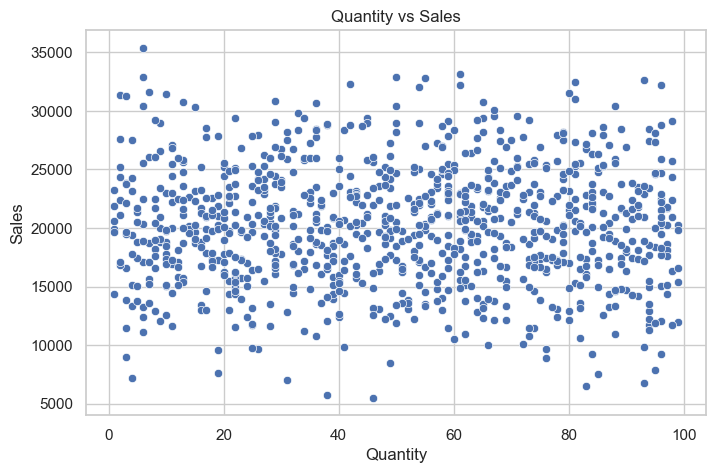

In [50]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Quantity',
                y='Sales',
                data=df)

plt.title("Quantity vs Sales")

plt.show()

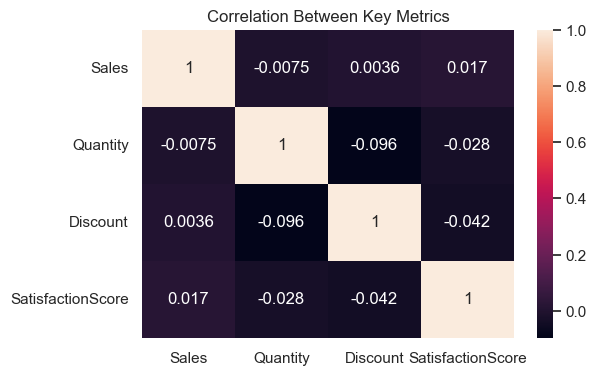

In [52]:
plt.figure(figsize=(6,4))

sns.heatmap(df[['Sales','Quantity','Discount','SatisfactionScore']].corr(),
            annot=True)

plt.title("Correlation Between Key Metrics")

plt.show()

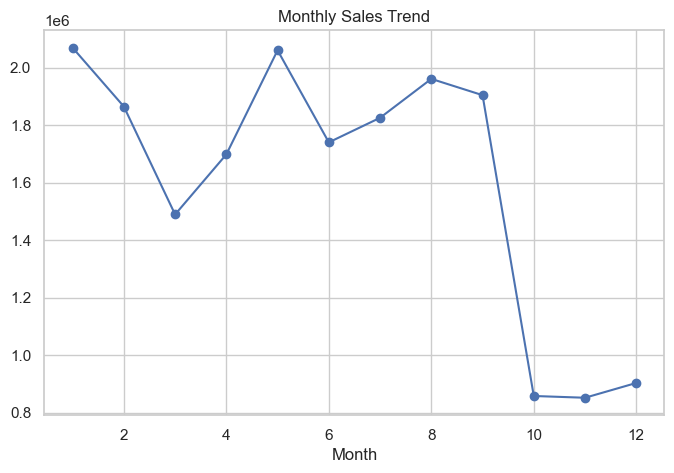

In [54]:
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(8,5))
monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")

plt.show()

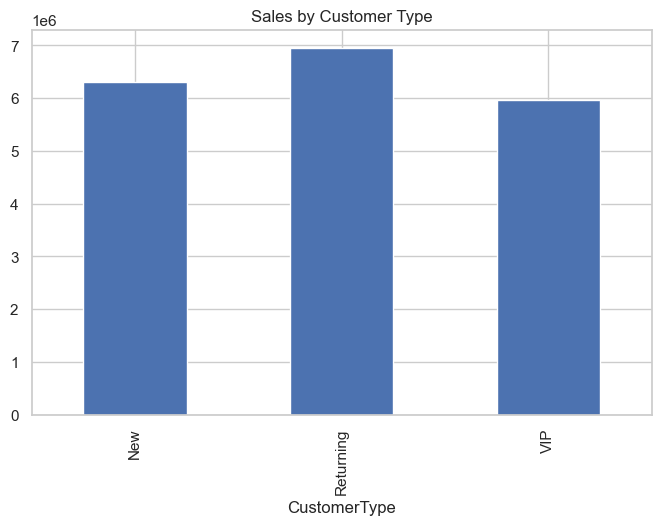

In [56]:
customer_sales = df.groupby('CustomerType')['Sales'].sum()

plt.figure(figsize=(8,5))
customer_sales.plot(kind='bar')

plt.title("Sales by Customer Type")

plt.show()

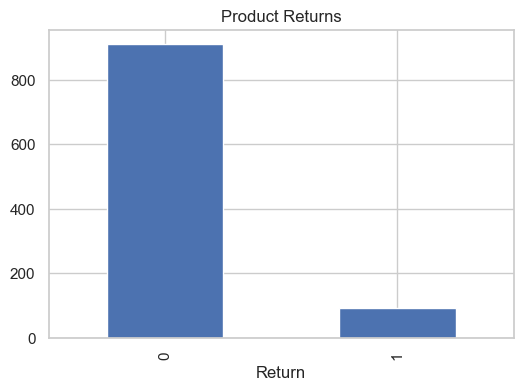

In [58]:
return_counts = df['Return'].value_counts()

plt.figure(figsize=(6,4))
return_counts.plot(kind='bar')

plt.title("Product Returns")

plt.show()

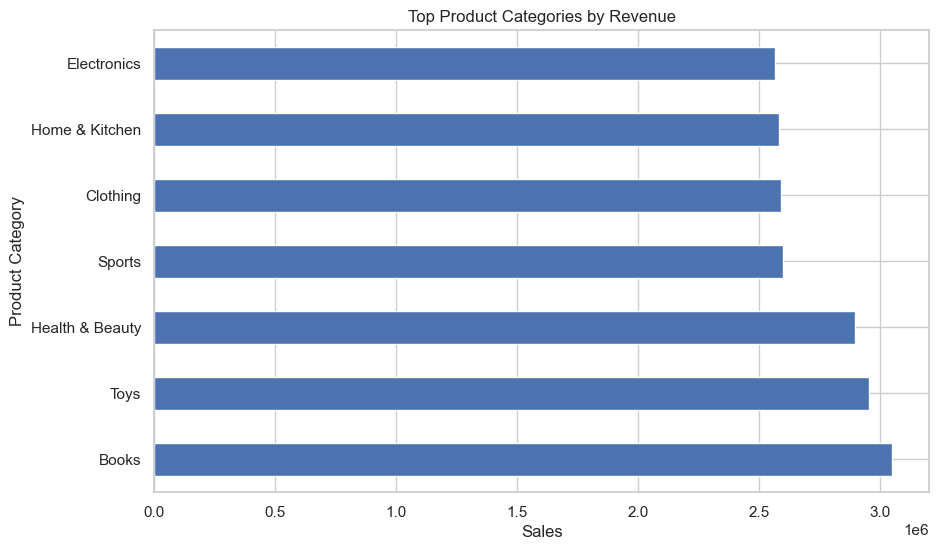

In [60]:
top_categories = df.groupby('ProductCategory')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
top_categories.plot(kind='barh')

plt.title("Top Product Categories by Revenue")
plt.xlabel("Sales")
plt.ylabel("Product Category")

plt.show()

In [ ]:
Top product categories contribute the majority of revenue.
Business should prioritize marketing these high-performing categories.

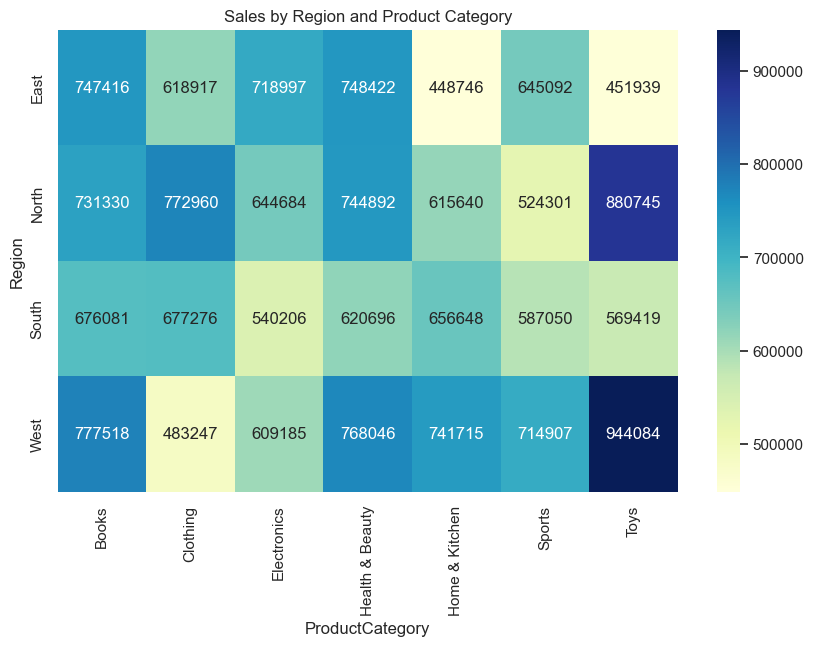

In [62]:
pivot_table = pd.pivot_table(
    df,
    values='Sales',
    index='Region',
    columns='ProductCategory',
    aggfunc='sum'
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")

plt.title("Sales by Region and Product Category")

plt.show()

In [ ]:
Certain regions show stronger demand for specific product categories.
Regional promotions can increase revenue.

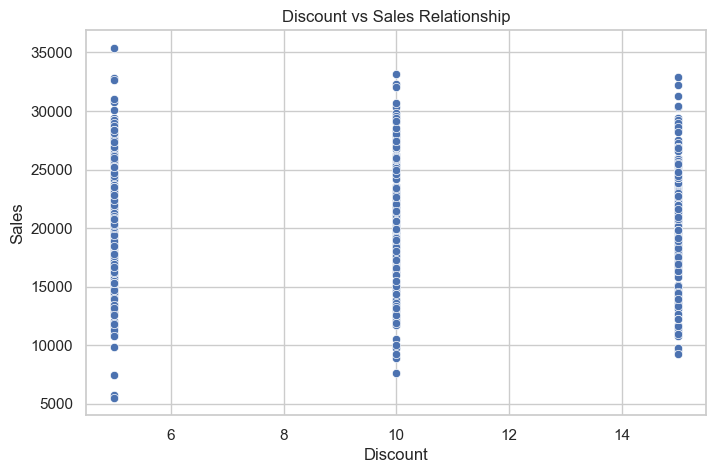

In [64]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Discount',
    y='Sales',
    data=df
)

plt.title("Discount vs Sales Relationship")

plt.xlabel("Discount")
plt.ylabel("Sales")

plt.show()

In [ ]:
Higher discounts may drive higher sales volume,
but excessive discounts could reduce profitability.

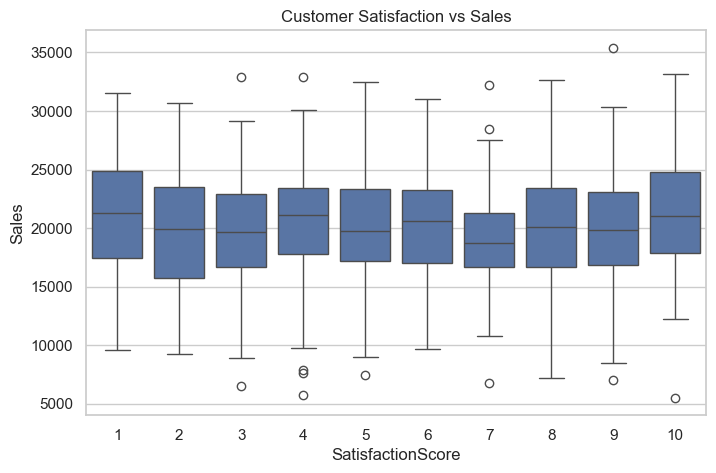

In [66]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='SatisfactionScore',
    y='Sales',
    data=df
)

plt.title("Customer Satisfaction vs Sales")

plt.show()

In [ ]:
Higher satisfaction scores tend to correlate with higher purchase value.
Improving customer experience could increase revenue.

In [19]:
df = pd.read_csv("../data/retail_sales_dataset.csv")

In [23]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

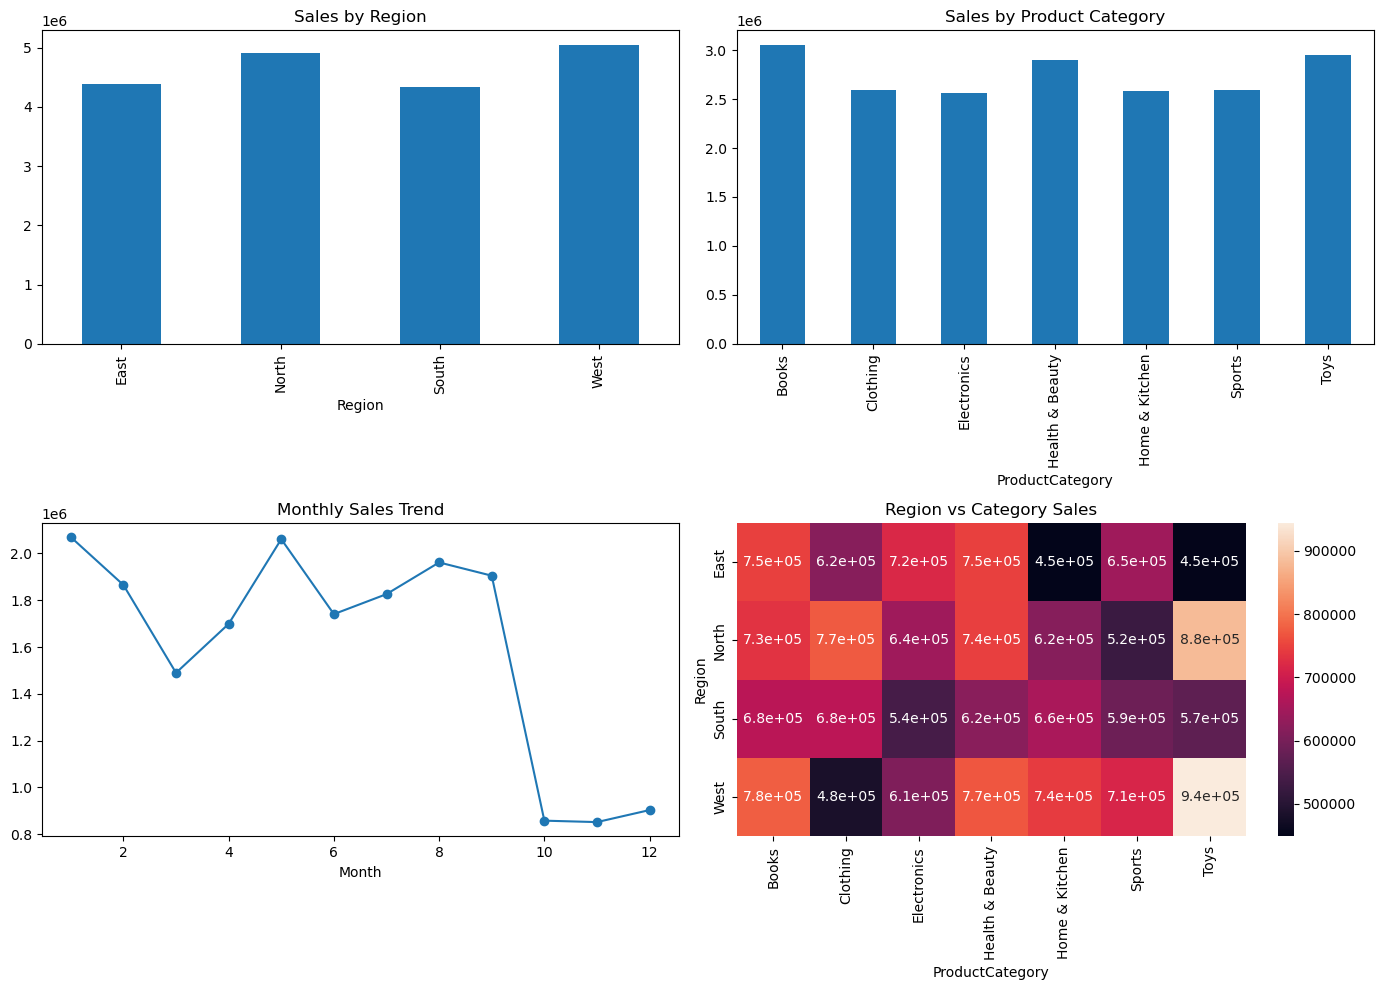

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("../dashboard", exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14,10))

region_sales = df.groupby('Region')['Sales'].sum()
region_sales.plot(kind='bar', ax=axes[0,0], title="Sales by Region")

category_sales = df.groupby('ProductCategory')['Sales'].sum()
category_sales.plot(kind='bar', ax=axes[0,1], title="Sales by Product Category")

monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales.plot(ax=axes[1,0], marker='o', title="Monthly Sales Trend")

pivot_table = df.pivot_table(values='Sales', index='Region', columns='ProductCategory', aggfunc='sum')
sns.heatmap(pivot_table, annot=True, ax=axes[1,1])

axes[1,1].set_title("Region vs Category Sales")

plt.tight_layout()

plt.savefig("../dashboard/retail_sales_dashboard.png")

plt.show()

In [ ]:
Key Insights :
1. Certain product categories generate the majority of revenue.
2. Some regions outperform others in sales performance.
3. Discounts influence purchasing behavior.
4. Customer satisfaction appears linked to higher spending.

In [ ]:
Business Recommendations:
1. Focus marketing efforts on top-performing product categories.
2. Strengthen sales strategies in high-demand regions.
3. Use targeted discounts to increase purchase volume.
4. Improve customer experience to increase satisfaction and sales.